<a href="https://colab.research.google.com/github/mengiejb-collab/CiaoDVDProject/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

add column names

In [2]:
df=pd.read_csv(
    "movie-ratings.txt",
    sep=",",
    header=None,
    names=[
    "userId",
    "movieId",
    "categoryID",
    "reviewID",
    "movieRating",
    "reviewDate"
    ]
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print(df.head)
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

<bound method NDFrame.head of        userId  movieId  categoryID  reviewID  movieRating  reviewDate
0           1        1           1         1            5  2000-07-12
1           2        1           1         2            5  2000-07-12
2           3        1           1         3            5  2000-07-12
3           4        1           1         4            4  2000-07-12
4           5        1           1         5            4  2000-07-12
...       ...      ...         ...       ...          ...         ...
72660    4808    16117          17     72661            5  2013-09-23
72661     119    16118          17     72662            3  2013-10-07
72662    5850    16119          17     72663            5  2013-10-09
72663     119    16120          17     72664            3  2013-10-31
72664     119    16121          17     72665            3  2013-11-11

[72665 rows x 6 columns]>
(72665, 6)
Index(['userId', 'movieId', 'categoryID', 'reviewID', 'movieRating',
       'reviewDate'],
 

In [5]:
num_users=df["userId"].nunique()
num_movies=df["movieId"].nunique()
num_ratings=len(df)

sparsity=1-(num_ratings/(num_users*num_movies))

print("Users:", num_users)
print("Movies:", num_movies)
print("Ratings:", num_ratings)
print("Sparsity:", sparsity)

Users: 17615
Movies: 16121
Ratings: 72665
Sparsity: 0.9997441115684126


Ratings distribution

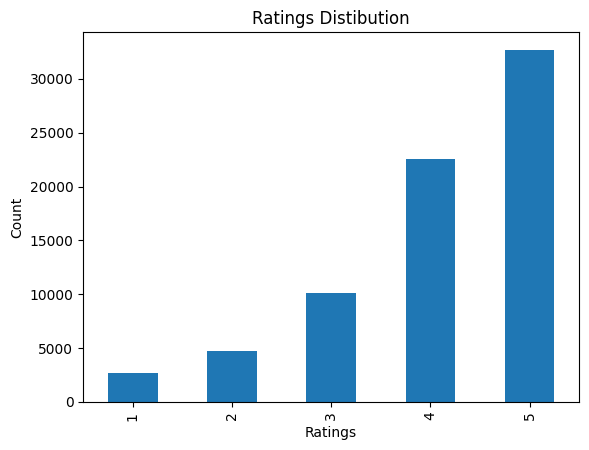

In [6]:
df["movieRating"].value_counts().sort_index().plot(kind="bar")
plt.title("Ratings Distibution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

Ratings per user

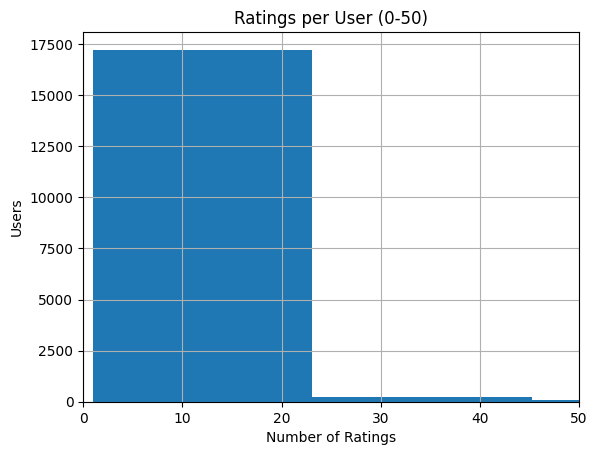

In [7]:
ratings_per_user=df.groupby("userId")["movieRating"].count()
ratings_per_user.hist(bins=50)
plt.xlim(0,50)
plt.title("Ratings per User (0-50)")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()

Ratings per Movie

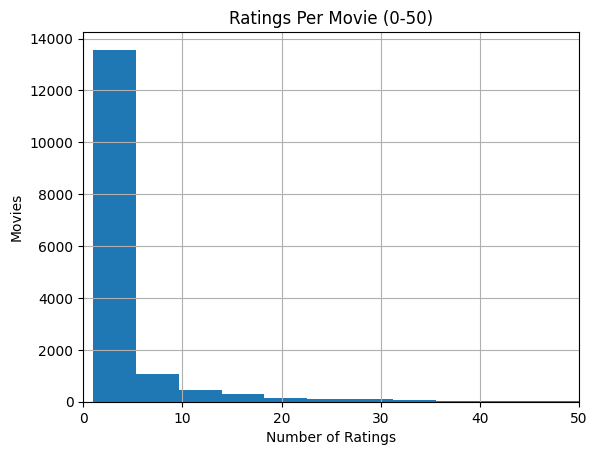

In [8]:
ratings_per_movie=df.groupby("movieId")["movieRating"].count()
ratings_per_movie.hist(bins=100)
plt.xlim(0,50)
plt.title("Ratings Per Movie (0-50)")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")
plt.show()


Remove duplicates

In [9]:
df.drop_duplicates(inplace=True)


Phase 2

Train/test split

In [10]:
!pip install numpy==1.26.4 scikit-surprise --no-cache-dir




In [11]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy
from surprise import KNNBasic
from surprise.prediction_algorithms.baseline_only import BaselineOnly

In [12]:
reader=Reader(rating_scale=(1, 5))

data=Dataset.load_from_df(df[["userId", "movieId", "movieRating"]], reader)

trainset, testset=train_test_split(data, test_size=0.2, random_state=42)

Model 1: Global Aveage Baseline

In [19]:
baseline=BaselineOnly()
baseline.fit(trainset)
pred1=baseline.test(testset)

rmse1=accuracy.rmse(pred1)
mae1=accuracy.mae(pred1)

print("RMSE:", rmse1)
print("MAE:", mae1)


Estimating biases using als...
RMSE: 0.9541
MAE:  0.7422
RMSE: 0.9540734200411405
MAE: 0.7421568937546047


Model 2:SVD

In [20]:
svd=SVD()
svd.fit(trainset)
pred2=svd.test(testset)
rmse2=accuracy.rmse(pred2)
mae2=accuracy.mae(pred2)

print("RMSE:", rmse2)
print("MAE:", mae2)

RMSE: 0.9566
MAE:  0.7385
RMSE: 0.9565671021119428
MAE: 0.7385278610451969


Compare results

      Model      RMSE       MAE
0  Baseline  0.954073  0.742157
1       SVD  0.956567  0.738528


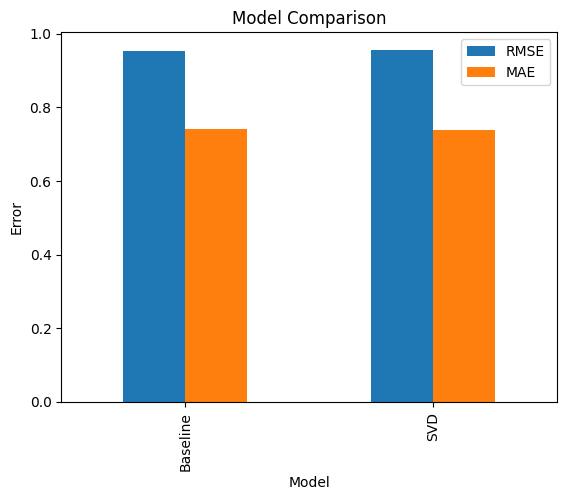

In [21]:
results=pd.DataFrame({
    "Model": ["Baseline", "SVD"],
    "RMSE":[rmse1, rmse2],
    "MAE":[mae1, mae2]
})
print(results)

#barchart

results.plot(x="Model", y=["RMSE", "MAE"], kind="bar")
plt.title("Model Comparison")
plt.ylabel("Error")
plt.show()

Pecision@k, Recall@k

In [35]:
from collections import defaultdict
from surprise import accuracy

def precision_recall_at_k(predictions, k=5, threshold=4):
    user_est_true=defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions={}
    recalls={}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel=sum((true_r >= threshold) for (_, true_r) in user_ratings)
        top_k=user_ratings[:k]
        n_rec_k=sum((est >= threshold) for (est, _) in top_k)
        n_rel_and_rec_k=sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in top_k
        )
        precisions[uid]=(n_rel_and_rec_k/n_rec_k if n_rec_k != 0 else 0
        )
        recalls[uid]=(
            n_rel_and_rec_k/n_rel if n_rel != 0 else 0
        )

    return(
        sum(precisions.values())/len(precisions),
        sum(recalls.values())/len(recalls)
    )

prec5, rec5=precision_recall_at_k(pred2, k=5)
prec10, rec10=precision_recall_at_k(pred2, k=10)

print("Precision@5:", prec5)
print("Recall@5:", rec5)
print("Precision@10:", prec10)
print("Recall@10:", rec10)

Precision@5: 0.7036422278162365
Recall@5: 0.6701351020063643
Precision@10: 0.70284495589719
Recall@10: 0.6762261292760913
